<a href="https://colab.research.google.com/github/marcushgrigsby39-web/Machine-Learning-with-python-Bootcamp./blob/main/Capstone_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Marcus H. Grigsby

**Part One: Logistic Regression Inference**

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib
import pandas as pd


# Load the dataset used for training
train_data_url = 'https://raw.githubusercontent.com/marcushgrigsby39-web/Machine-Learning-with-python-Bootcamp./refs/heads/main/new_customers_200.csv'
df_train = pd.read_csv(train_data_url)

print("Training data loaded. First 5 rows:")
display(df_train.head())

Training data loaded. First 5 rows:


,Age,Salary
0,25,52000
1,42,89000
2,33,62000
3,55,105000
4,29,48000


In [37]:
# Define features (X) and target (y) for training
X_train_data = df_train[['Age', 'Salary']]
y_train_data = df_train['Status']

print("Features (X) and target (y) defined.")

Features (X) and target (y) defined.


In [36]:
# Split the training data to simulate a full training pipeline (though we will use all for fitting scaler and model here)
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(X_train_data, y_train_data, test_size=0.25, random_state=0)

# Initialize and fit StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_split)

# Initialize and train Logistic Regression model
model = LogisticRegression(random_state=0)
model.fit(X_train_scaled, y_train_split)

print("Logistic Regression Model and StandardScaler trained successfully!")

# Save the trained model and scaler to ensure they are available in memory for the next cell
# (We are not saving to disk as the next cell will use the in-memory objects directly)
# These 'model' and 'scaler' objects will now be available for the inference task.

Logistic Regression Model and StandardScaler trained successfully!



First 10 rows with prediction:
   Age  Salary  Predicted_Class  Probability_Buying
0   25   52000                0            0.013500
1   42   89000                1            0.574372
2   33   62000                0            0.084434
3   55  105000                1            0.967437
4   29   48000                0            0.025473
5   38   75000                0            0.276670
6   45   92000                1            0.729008
7   31   58000                0            0.051579
8   50   98000                1            0.897844
9   27   51000                0            0.019194

Number of customers predicted to buy: 159
Average probability of buying: 0.832092


/tmp/ipykernel_7000/2537754524.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Predicted_Class',


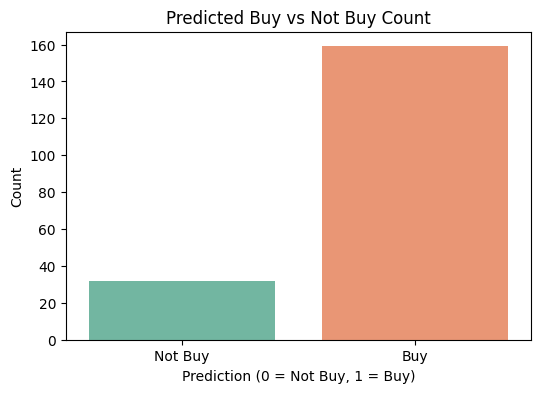

In [38]:
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import os

# Removed file download logic as model and scaler are now trained in-memory

# Using the 'model' and 'scaler' objects that were trained in the previous cells
# These objects are already available in the current Colab runtime environment

# Reverting to the correct dataset for this inference task
url = "https://raw.githubusercontent.com/welickermah-glitch/Machine-Learning-with-Python-Boot-Camp/main/new_customers_200.csv"
df = pd.read_csv(url)

# 2. Explore

# 3. Prepare features
# Correcting 'new_df' to 'df' and ensuring correct feature columns
X_new = df[['Age', 'Salary']]


# 4. Scale features and predict
X_new_scaled = scaler.transform(X_new)
df['Predicted_Class'] = model.predict(X_new_scaled)
df['Probability_Buying'] = model.predict_proba(X_new_scaled)[:, 1]


# 5. Print required output
print("\nFirst 10 rows with prediction:")
print(df.head(10))

num_buyers = df['Predicted_Class'].sum()
avg_prob = df['Probability_Buying'].mean()

print(f"\nNumber of customers predicted to buy: {num_buyers}")
print(f"Average probability of buying: {avg_prob:4f}")

# 6. Visualization
plt.figure(figsize=(6,4))
sns.countplot(x='Predicted_Class',
              data=df, palette='Set2')
plt.title('Predicted Buy vs Not Buy Count')
plt.xlabel('Prediction (0 = Not Buy, 1 = Buy)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Not Buy', 'Buy'])
plt.savefig('part1_bar_chart.png')
plt.show()

# 7. Save predictions
df.to_csv('part1_predictions.csv', index=False)

**Part 2: Maintenance Prediction**


First 5 rows:
   Age_Years  Mileage_km  Engine_L  High_Maintenance
0          2          30       1.8                 0
1          5          80       2.0                 1
2          1          15       1.5                 0
3          8         120       2.5                 1
4         10         180       1.4                 1

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age_Years         150 non-null    int64  
 1   Mileage_km        150 non-null    int64  
 2   Engine_L          150 non-null    float64
 3   High_Maintenance  150 non-null    int64  
dtypes: float64(1), int64(3)
memory usage: 4.8 KB
None
Dataset Shape: (150, 4)

Missing values:
Age_Years           0
Mileage_km          0
Engine_L            0
High_Maintenance    0
dtype: int64

Accuracy: 100.0000%
Precision: 1.0000
Recall: 1.0000
F1 Score: 1.000

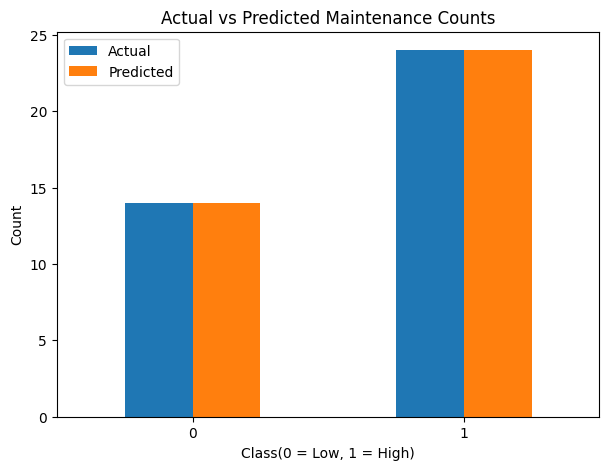

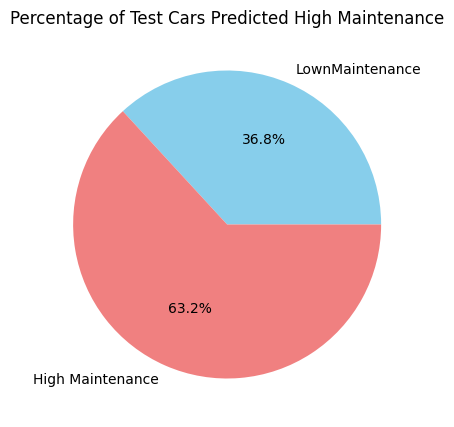

['car_maintenance_model.pkl']

In [ ]:
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import  accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import pandas as pd # Added this import, as df is used without pd being imported.
import matplotlib.pyplot as plt # Added this import, as plt is used without being imported.
import joblib # Added to fix NameError for joblib

url = "https://raw.githubusercontent.com/welickermah-glitch/Machine-Learning-with-Python-Boot-Camp/refs/heads/main/liberia_cars_maintenance.csv"
df = pd.read_csv(url)

# 2. Explore
print("\nFirst 5 rows:")
print(df.head())
print("\nDataset info:") # Corrected "n\Dataset info:" to "\nDataset info:"
print(df.info())
print(f"Dataset Shape: {df.shape}")
print("\nMissing values:")
print(df.isnull().sum())

# 3. Define features and target
X = df[['Age_Years', 'Mileage_km', 'Engine_L']]
y = df['High_Maintenance']

# 4. Split data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=0) # Corrected test_split to test_size


# 5. Train Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=0)
dt_model.fit(X_train, y_train)

# 6. Predict and Evaluate
y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nAccuracy: {accuracy:.4%}") # Formatted percentage correctly
print(f"Precision: {precision:.4f}") # Formatted to 4 decimal places
print(f"Recall: {recall:.4f}") # Formatted to 4 decimal places
print(f"F1 Score: {f1:.4f}") # Formatted to 4 decimal places
print("\nConfusion Matrix:")
print(cm)

# 7. Visualization
# Chart 1: Bar chart comparing actual vs predicted
pred_counts = pd.DataFrame({'Actual':
                            y_test.value_counts().sort_index(),
                            'Predicted':
                            pd.Series(y_pred).value_counts().sort_index()
                            })
pred_counts.plot(kind='bar', figsize=(7,5))
plt.title('Actual vs Predicted Maintenance Counts')
plt.xlabel('Class(0 = Low, 1 = High)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig('part2_bar_chart.png')
plt.show()

# Chart 2: Pie Chart of predicted high maintenance
high_maintenance_pct = (y_pred.sum()/len(y_pred))*100
low_maintenance_pct = 100 - high_maintenance_pct

plt.figure(figsize=(5,5))
plt.pie([low_maintenance_pct, high_maintenance_pct], labels=['LownMaintenance', 'High Maintenance'],
       autopct='%1.1f%%', colors=['skyblue', 'lightcoral'] )
plt.title('Percentage of Test Cars Predicted High Maintenance')
plt.savefig('part_pie_chart.png')
plt.show()

# 8. Save Model
joblib.dump(dt_model, 'car_maintenance_model.pkl')